# 2025년 12월 관심집단수 EDA

이 노트북은 `2025.12월_10개 관심집단수.csv`를 대상으로 전처리, 기술통계, 자치구/연령대/성별 비교, 행정동 랭킹, 상관관계 분석을 수행합니다.

- 분석 단위: 행정동코드, 자치구, 행정동명, 성별, 연령대
- 주요 관심집단 수치는 절대값과 비율을 함께 확인합니다.
- 성별 코드는 `1=남성`, `2=여성`으로 가정합니다.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='talk')

# 윈도우 한글 폰트를 우선 적용합니다. 폰트가 없으면 기본 폰트를 사용합니다.
font_candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic']
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
selected_font = next((font for font in font_candidates if font in available_fonts), None)
if selected_font:
    rcParams['font.family'] = selected_font
else:
    print('경고: 한글 폰트를 찾지 못했습니다. 일부 그래프 레이블이 깨질 수 있습니다.')
rcParams['axes.unicode_minus'] = False

DATA_PATH = Path.cwd() / '2025.12월_10개 관심집단수.csv'
DATA_PATH

WindowsPath('C:/Users/82102/Desktop/파동/2025.12월_10개 관심집단수.csv')

In [2]:
def load_csv_with_fallback(path: Path) -> pd.DataFrame:
    last_error = None
    for encoding in ['cp949', 'utf-8-sig']:
        try:
            return pd.read_csv(path, encoding=encoding)
        except Exception as exc:
            last_error = exc
    raise last_error

raw_df = load_csv_with_fallback(DATA_PATH)
raw_df = raw_df.loc[:, [col for col in raw_df.columns if str(col).strip() and not str(col).startswith('Unnamed:')]].copy()

print(f'원본 데이터 크기: {raw_df.shape[0]:,}행 x {raw_df.shape[1]:,}열')
print('\n컬럼 목록')
print(raw_df.columns.tolist())
raw_df.head()

원본 데이터 크기: 10,176행 x 17열

컬럼 목록
['행정동코드', '자치구', '행정동명', '성별', '연령대', '총인구', '1인가구수', '커뮤니케이션이 적은 집단', '평일 외출이 적은 집단', '휴일 외출이 적은 집단', '출근소요시간 및 근무시간이 많은 집단', '외출이 매우 적은 집단(전체)', '외출이 매우 많은 집단', '동영상서비스 이용이 많은 집단', '생활서비스 이용이 많은 집단', '재정상태에 대한 관심집단', '외출-커뮤니케이션이 모두 적은 집단(전체)']


,행정동코드,자치구,행정동명,성별,연령대,총인구,1인가구수,커뮤니케이션이 적은 집단,평일 외출이 적은 집단,휴일 외출이 적은 집단,출근소요시간 및 근무시간이 많은 집단,외출이 매우 적은 집단(전체),외출이 매우 많은 집단,동영상서비스 이용이 많은 집단,생활서비스 이용이 많은 집단,재정상태에 대한 관심집단,외출-커뮤니케이션이 모두 적은 집단(전체)
0,1101053,종로구,사직동,1,20,173,52,3,6,7,7,3,4,7,1,2,0
1,1101053,종로구,사직동,1,25,300,93,12,9,8,14,9,9,16,10,13,28
2,1101053,종로구,사직동,1,30,354,114,21,16,7,17,14,17,19,13,8,7
3,1101053,종로구,사직동,1,35,360,104,27,14,6,13,18,15,21,8,8,12
4,1101053,종로구,사직동,1,40,372,87,17,10,8,11,18,8,17,4,7,14


## 1. 전처리

수치 컬럼의 공백을 제거하고 숫자형으로 변환한 뒤, 성별 라벨과 비율 파생 컬럼을 생성합니다.

In [3]:
df = raw_df.copy()

id_cols = ['행정동코드', '자치구', '행정동명', '성별', '연령대']
numeric_cols = [col for col in df.columns if col not in id_cols]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.strip()
        .replace({'': np.nan, 'nan': np.nan})
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['행정동코드'] = pd.to_numeric(df['행정동코드'], errors='coerce').astype('Int64')
df['성별'] = pd.to_numeric(df['성별'], errors='coerce').astype('Int64')
df['연령대'] = pd.to_numeric(df['연령대'], errors='coerce').astype('Int64')

df['성별라벨'] = df['성별'].map({1: '남성', 2: '여성'}).fillna('기타')

count_cols = [col for col in numeric_cols if col not in ['총인구']]
ratio_target_cols = [col for col in count_cols]

for col in ratio_target_cols:
    ratio_col = f'{col}비율'
    df[ratio_col] = np.where(df['총인구'] > 0, df[col] / df['총인구'], np.nan)

ratio_cols = [f'{col}비율' for col in ratio_target_cols]

print(f'전처리 후 데이터 크기: {df.shape[0]:,}행 x {df.shape[1]:,}열')
df.head()

전처리 후 데이터 크기: 10,176행 x 29열


,행정동코드,자치구,행정동명,성별,연령대,총인구,1인가구수,커뮤니케이션이 적은 집단,평일 외출이 적은 집단,휴일 외출이 적은 집단,출근소요시간 및 근무시간이 많은 집단,외출이 매우 적은 집단(전체),외출이 매우 많은 집단,동영상서비스 이용이 많은 집단,생활서비스 이용이 많은 집단,재정상태에 대한 관심집단,외출-커뮤니케이션이 모두 적은 집단(전체),성별라벨,1인가구수비율,커뮤니케이션이 적은 집단비율,평일 외출이 적은 집단비율,휴일 외출이 적은 집단비율,출근소요시간 및 근무시간이 많은 집단비율,외출이 매우 적은 집단(전체)비율,외출이 매우 많은 집단비율,동영상서비스 이용이 많은 집단비율,생활서비스 이용이 많은 집단비율,재정상태에 대한 관심집단비율,외출-커뮤니케이션이 모두 적은 집단(전체)비율
0,1101053,종로구,사직동,1,20,173,52,3,6,7,7,3,4,7,1,2,0,남성,0.3006,0.0173,0.0347,0.0405,0.0405,0.0173,0.0231,0.0405,0.0058,0.0116,0.0000
1,1101053,종로구,사직동,1,25,300,93,12,9,8,14,9,9,16,10,13,28,남성,0.3100,0.0400,0.0300,0.0267,0.0467,0.0300,0.0300,0.0533,0.0333,0.0433,0.0933
2,1101053,종로구,사직동,1,30,354,114,21,16,7,17,14,17,19,13,8,7,남성,0.3220,0.0593,0.0452,0.0198,0.0480,0.0395,0.0480,0.0537,0.0367,0.0226,0.0198
3,1101053,종로구,사직동,1,35,360,104,27,14,6,13,18,15,21,8,8,12,남성,0.2889,0.0750,0.0389,0.0167,0.0361,0.0500,0.0417,0.0583,0.0222,0.0222,0.0333
4,1101053,종로구,사직동,1,40,372,87,17,10,8,11,18,8,17,4,7,14,남성,0.2339,0.0457,0.0269,0.0215,0.0296,0.0484,0.0215,0.0457,0.0108,0.0188,0.0376


In [4]:
overview = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    '결측치수': df.isna().sum(),
    '결측치비율': df.isna().mean()
}).sort_values(['결측치수', 'dtype'], ascending=[False, True])

print('고유 자치구 수:', df['자치구'].nunique())
print('고유 행정동명 수:', df['행정동명'].nunique())
print('성별 값:', sorted(df['성별라벨'].dropna().unique().tolist()))
print('연령대 값:', sorted(df['연령대'].dropna().unique().tolist()))
overview.head(20)

고유 자치구 수: 25
고유 행정동명 수: 423
성별 값: ['남성', '여성']
연령대 값: [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75]


,dtype,결측치수,결측치비율
행정동코드,Int64,0,0.0000
성별,Int64,0,0.0000
연령대,Int64,0,0.0000
1인가구수비율,float64,0,0.0000
커뮤니케이션이 적은 집단비율,float64,0,0.0000
평일 외출이 적은 집단비율,float64,0,0.0000
휴일 외출이 적은 집단비율,float64,0,0.0000
출근소요시간 및 근무시간이 많은 집단비율,float64,0,0.0000
외출이 매우 적은 집단(전체)비율,float64,0,0.0000
외출이 매우 많은 집단비율,float64,0,0.0000


## 2. 기술통계와 분포 확인

절대값 기준의 기본 분포와 주요 비율 분포를 확인합니다.

In [5]:
summary_cols = ['총인구', '1인가구수'] + count_cols[:]
df[summary_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
총인구,"10,176.0000",859.7200,417.7300,28.0000,577.0000,796.0000,"1,070.0000","6,714.0000"
1인가구수,"10,176.0000",166.7500,183.9600,5.0000,73.0000,118.0000,190.0000,"3,686.0000"
1인가구수,"10,176.0000",166.7500,183.9600,5.0000,73.0000,118.0000,190.0000,"3,686.0000"
커뮤니케이션이 적은 집단,"10,176.0000",16.6800,18.6200,0.0000,6.0000,11.0000,20.0000,375.0000
평일 외출이 적은 집단,"10,176.0000",16.6800,19.8400,0.0000,6.0000,11.0000,20.0000,295.0000
휴일 외출이 적은 집단,"10,176.0000",16.6800,22.2000,0.0000,5.0000,11.0000,20.0000,678.0000
출근소요시간 및 근무시간이 많은 집단,"10,176.0000",16.6800,22.4000,0.0000,6.0000,11.0000,20.0000,480.0000
외출이 매우 적은 집단(전체),"10,176.0000",17.2300,13.1800,0.0000,8.0000,14.0000,24.0000,163.0000
외출이 매우 많은 집단,"10,176.0000",15.6000,16.6100,0.0000,3.0000,10.0000,22.0000,255.0000
동영상서비스 이용이 많은 집단,"10,176.0000",16.6700,19.6000,0.0000,6.0000,11.0000,20.0000,376.0000


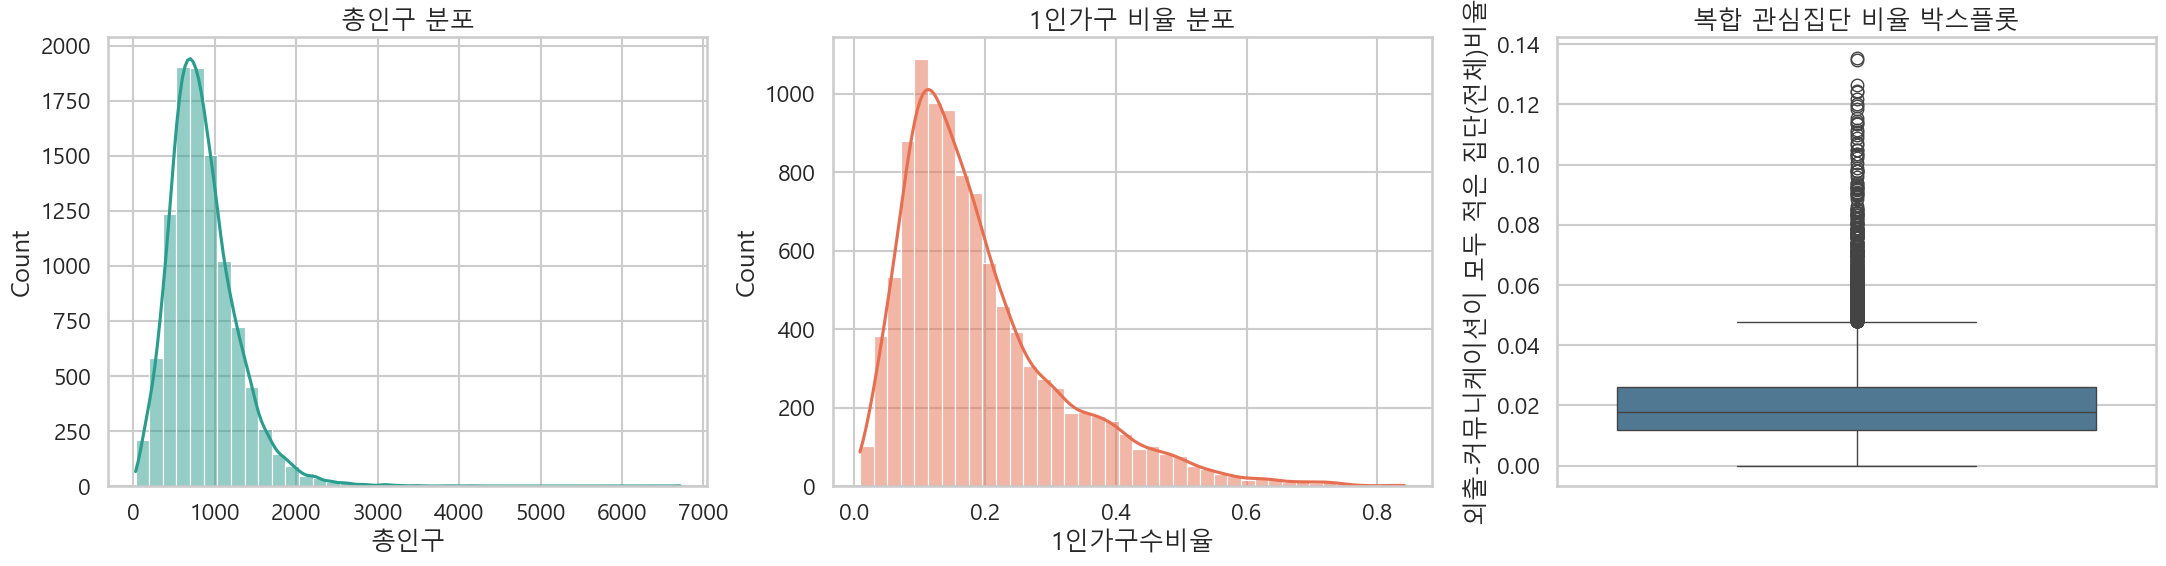

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.histplot(df['총인구'].dropna(), bins=40, kde=True, ax=axes[0], color='#2a9d8f')
axes[0].set_title('총인구 분포')

sns.histplot(df['1인가구수비율'].dropna(), bins=40, kde=True, ax=axes[1], color='#e76f51')
axes[1].set_title('1인가구 비율 분포')

focus_ratio = '외출-커뮤니케이션이 모두 적은 집단(전체)비율'
sns.boxplot(y=df[focus_ratio], ax=axes[2], color='#457b9d')
axes[2].set_title('복합 관심집단 비율 박스플롯')

plt.tight_layout()
plt.show()

## 3. 자치구 단위 집계

자치구별로 절대 규모와 관심집단 비율을 함께 비교합니다.

In [7]:
district_sum_cols = ['총인구'] + count_cols
district_df = df.groupby('자치구', as_index=False)[district_sum_cols].sum(numeric_only=True)

for col in count_cols:
    district_df[f'{col}비율'] = np.where(district_df['총인구'] > 0, district_df[col] / district_df['총인구'], np.nan)

district_view = district_df[['자치구', '총인구', '1인가구수', '1인가구수비율', '재정상태에 대한 관심집단비율', '외출-커뮤니케이션이 모두 적은 집단(전체)비율']]
district_view.sort_values('총인구', ascending=False).head(10)

,자치구,총인구,1인가구수,1인가구수비율,재정상태에 대한 관심집단비율,외출-커뮤니케이션이 모두 적은 집단(전체)비율
17,송파구,584710,88767,0.1518,0.0143,0.0183
3,강서구,512583,97361,0.1899,0.0203,0.0188
0,강남구,505241,90314,0.1788,0.0155,0.0203
4,관악구,465082,147780,0.3178,0.0377,0.0193
8,노원구,442661,68556,0.1549,0.0166,0.0204
1,강동구,422983,69349,0.1640,0.0145,0.0197
21,은평구,405346,69413,0.1712,0.0181,0.0199
6,구로구,393720,69402,0.1763,0.0176,0.0233
16,성북구,391027,72120,0.1844,0.0180,0.0169
18,양천구,386409,49696,0.1286,0.0129,0.0168


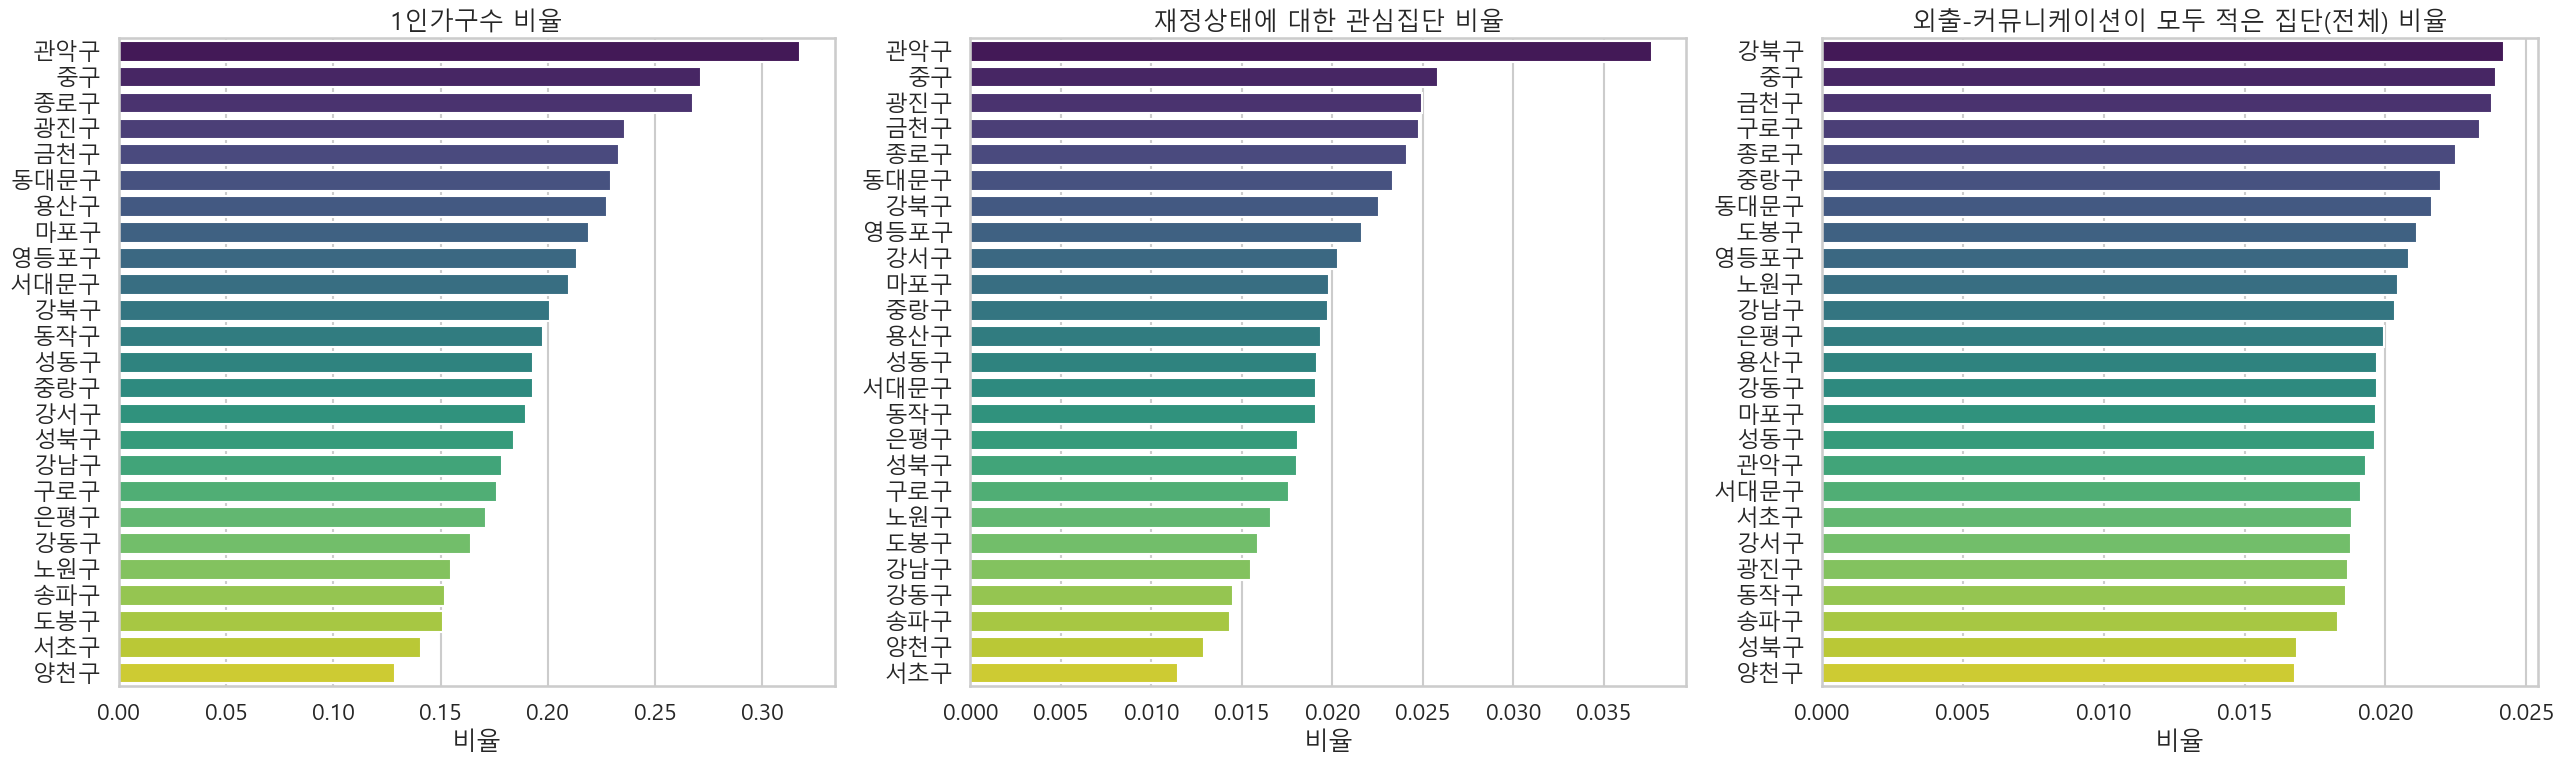

In [8]:
plot_cols = ['1인가구수비율', '재정상태에 대한 관심집단비율', '외출-커뮤니케이션이 모두 적은 집단(전체)비율']
fig, axes = plt.subplots(1, 3, figsize=(26, 8))

for ax, col in zip(axes, plot_cols):
    top_plot = district_df.sort_values(col, ascending=False)
    sns.barplot(data=top_plot, x=col, y='자치구', ax=ax, palette='viridis')
    ax.set_title(col.replace('비율', ' 비율'))
    ax.set_xlabel('비율')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

## 4. 연령대 및 성별 비교

연령대와 성별 축에서 관심집단 비율이 어떻게 달라지는지 살펴봅니다.

In [9]:
selected_ratio_cols = [
    '1인가구수비율',
    '커뮤니케이션이 적은 집단비율',
    '동영상서비스 이용이 많은 집단비율',
    '재정상태에 대한 관심집단비율',
    '외출-커뮤니케이션이 모두 적은 집단(전체)비율'
]

age_gender_df = df.groupby(['연령대', '성별라벨'], as_index=False)[selected_ratio_cols].mean(numeric_only=True)
age_gender_df.head()

,연령대,성별라벨,1인가구수비율,커뮤니케이션이 적은 집단비율,동영상서비스 이용이 많은 집단비율,재정상태에 대한 관심집단비율,외출-커뮤니케이션이 모두 적은 집단(전체)비율
0,20,남성,0.2089,0.0265,0.0260,0.0188,0.0213
1,20,여성,0.2220,0.0188,0.0143,0.0132,0.0129
2,25,남성,0.2194,0.0261,0.0280,0.0297,0.0238
3,25,여성,0.2315,0.0166,0.0174,0.0252,0.0156
4,30,남성,0.2270,0.0255,0.0253,0.0237,0.0195


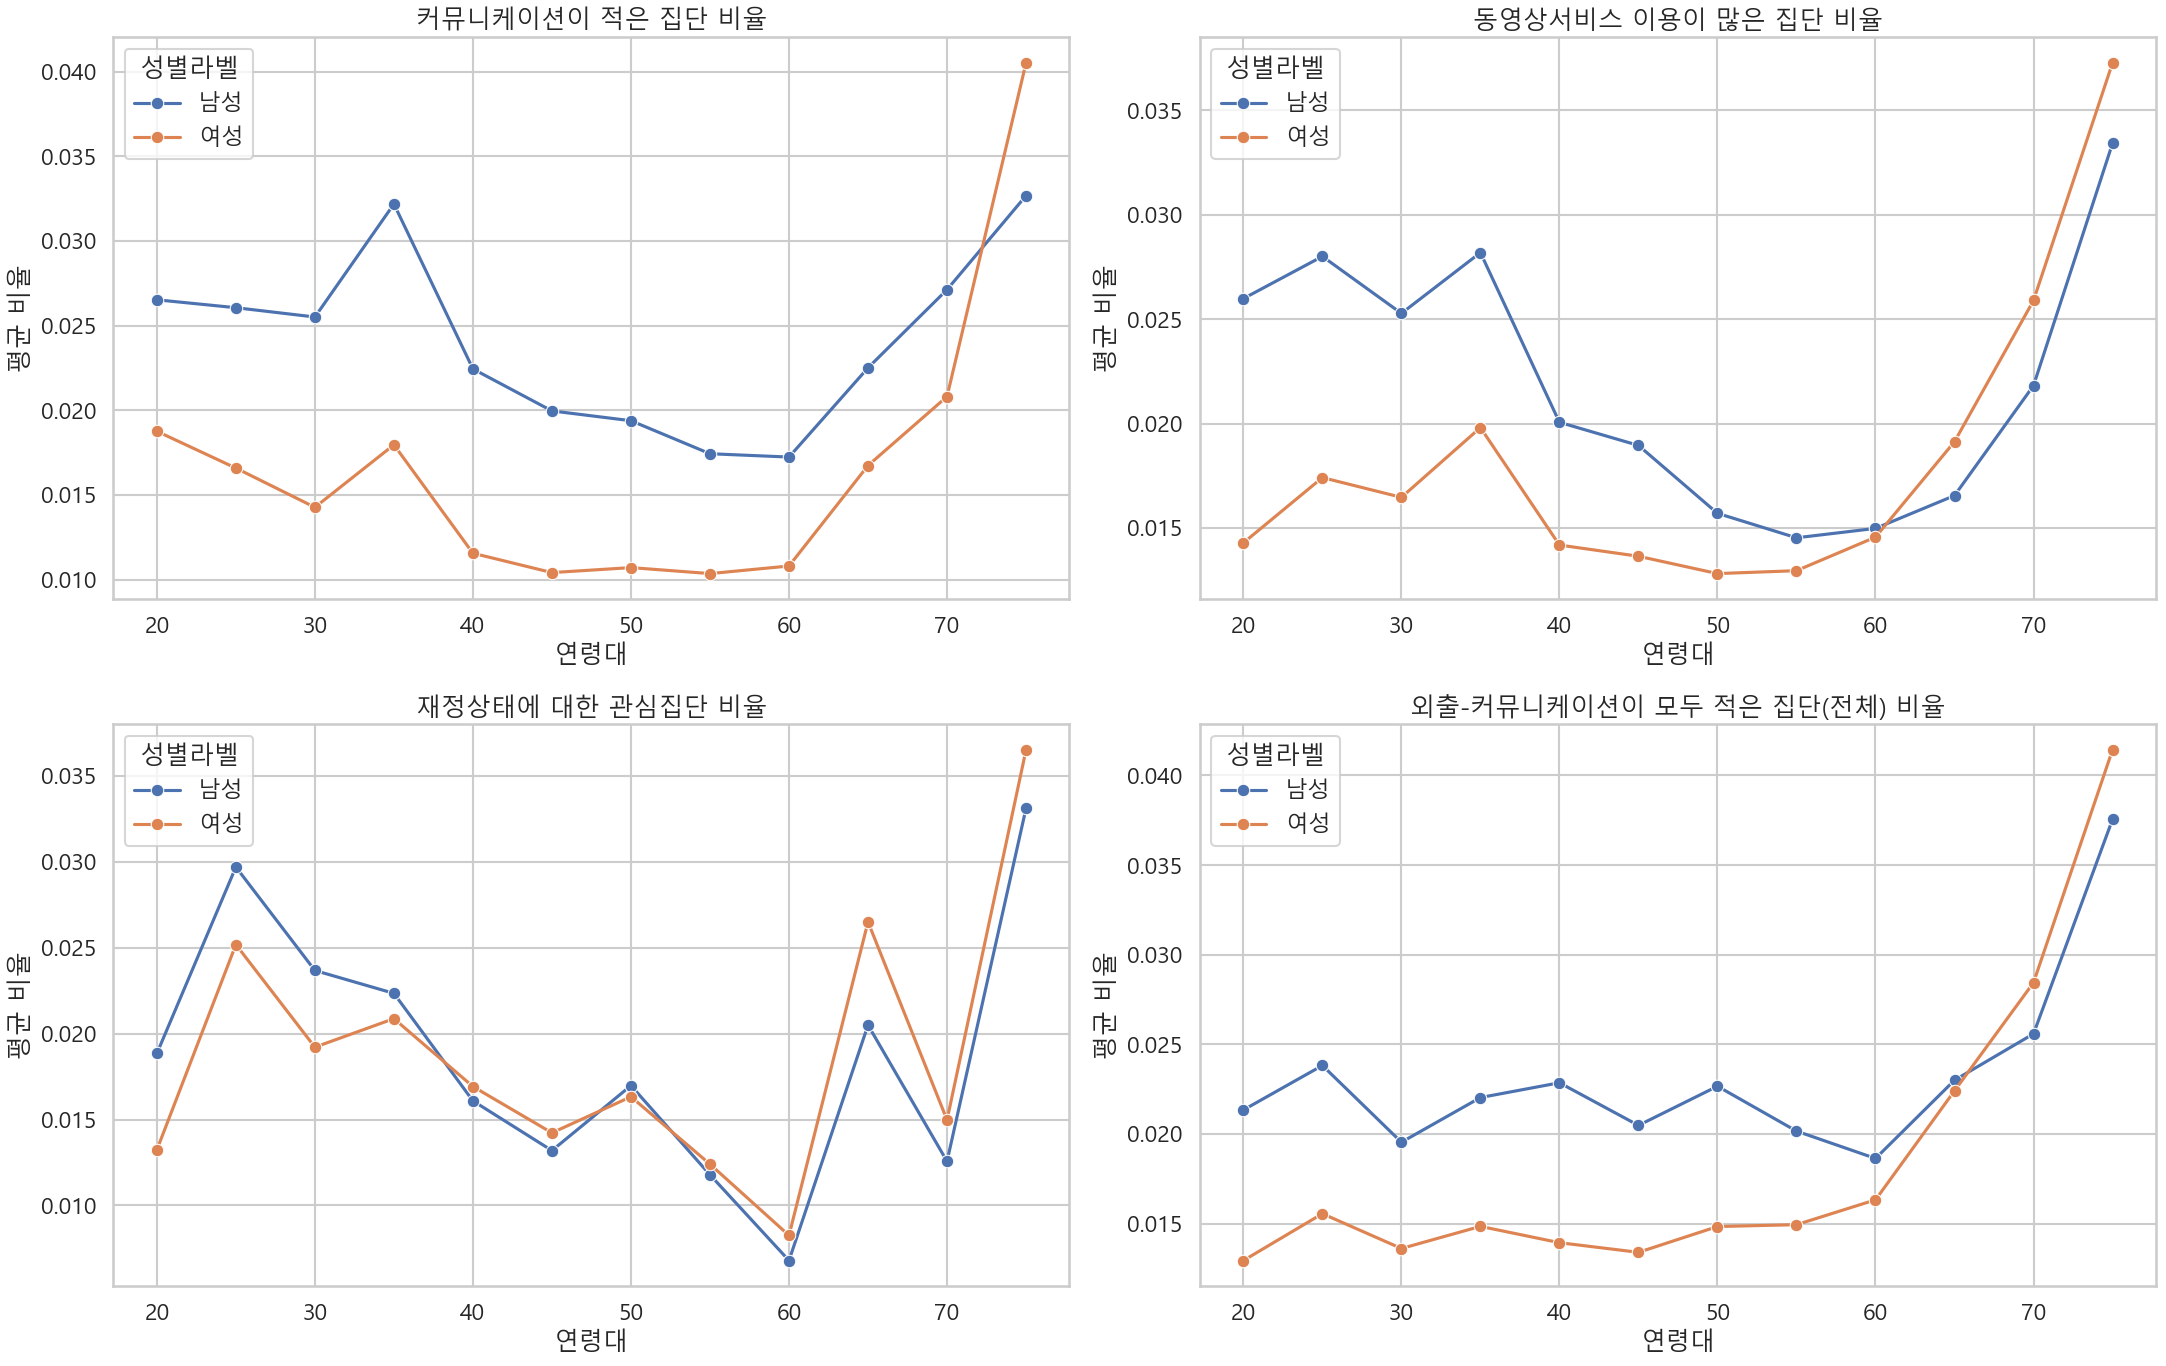

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(22, 14))
axes = axes.ravel()
line_targets = selected_ratio_cols[1:]

for ax, col in zip(axes, line_targets):
    sns.lineplot(data=age_gender_df, x='연령대', y=col, hue='성별라벨', marker='o', ax=ax)
    ax.set_title(col.replace('비율', ' 비율'))
    ax.set_xlabel('연령대')
    ax.set_ylabel('평균 비율')

plt.tight_layout()
plt.show()

## 5. 행정동 랭킹

성별과 연령대를 합산한 뒤 행정동 단위의 관심집단 비율 상위/하위를 비교합니다. 아주 작은 모집단 왜곡을 줄이기 위해 총인구 1,000명 이상 행정동만 비교합니다.

In [11]:
dong_df = df.groupby(['행정동코드', '자치구', '행정동명'], as_index=False)[district_sum_cols].sum(numeric_only=True)
for col in count_cols:
    dong_df[f'{col}비율'] = np.where(dong_df['총인구'] > 0, dong_df[col] / dong_df['총인구'], np.nan)

dong_filtered = dong_df[dong_df['총인구'] >= 1000].copy()
rank_col = '외출-커뮤니케이션이 모두 적은 집단(전체)비율'

top_dong = dong_filtered.nlargest(15, rank_col)[['자치구', '행정동명', '총인구', rank_col]]
bottom_dong = dong_filtered.nsmallest(15, rank_col)[['자치구', '행정동명', '총인구', rank_col]]

print('상위 15개 행정동')
display(top_dong)
print('\n하위 15개 행정동')
display(bottom_dong)

상위 15개 행정동


,자치구,행정동명,총인구,외출-커뮤니케이션이 모두 적은 집단(전체)비율
19,중구,명동,4237,0.0805
17,중구,소공동,2940,0.0633
18,중구,회현동,4947,0.0542
23,중구,을지로동,3102,0.0474
7,종로구,종로1·2·3·4가동,10490,0.0455
59,성동구,성수2가3동,10307,0.0383
172,노원구,상계3·4동,22818,0.0373
40,용산구,이태원1동,7056,0.0367
251,강서구,가양2동,15516,0.0364
148,도봉구,방학2동,17428,0.0361



하위 15개 행정동


,자치구,행정동명,총인구,외출-커뮤니케이션이 모두 적은 집단(전체)비율
118,성북구,길음1동,27954,0.0115
240,강서구,염창동,34581,0.0120
236,양천구,신정6동,20661,0.0124
162,노원구,하계2동,18174,0.0128
112,성북구,안암동,17490,0.0130
140,강북구,삼각산동,24426,0.0132
369,강남구,개포4동,19045,0.0133
153,도봉구,창4동,24091,0.0134
324,관악구,남현동,16936,0.0135
242,강서구,등촌2동,17623,0.0136


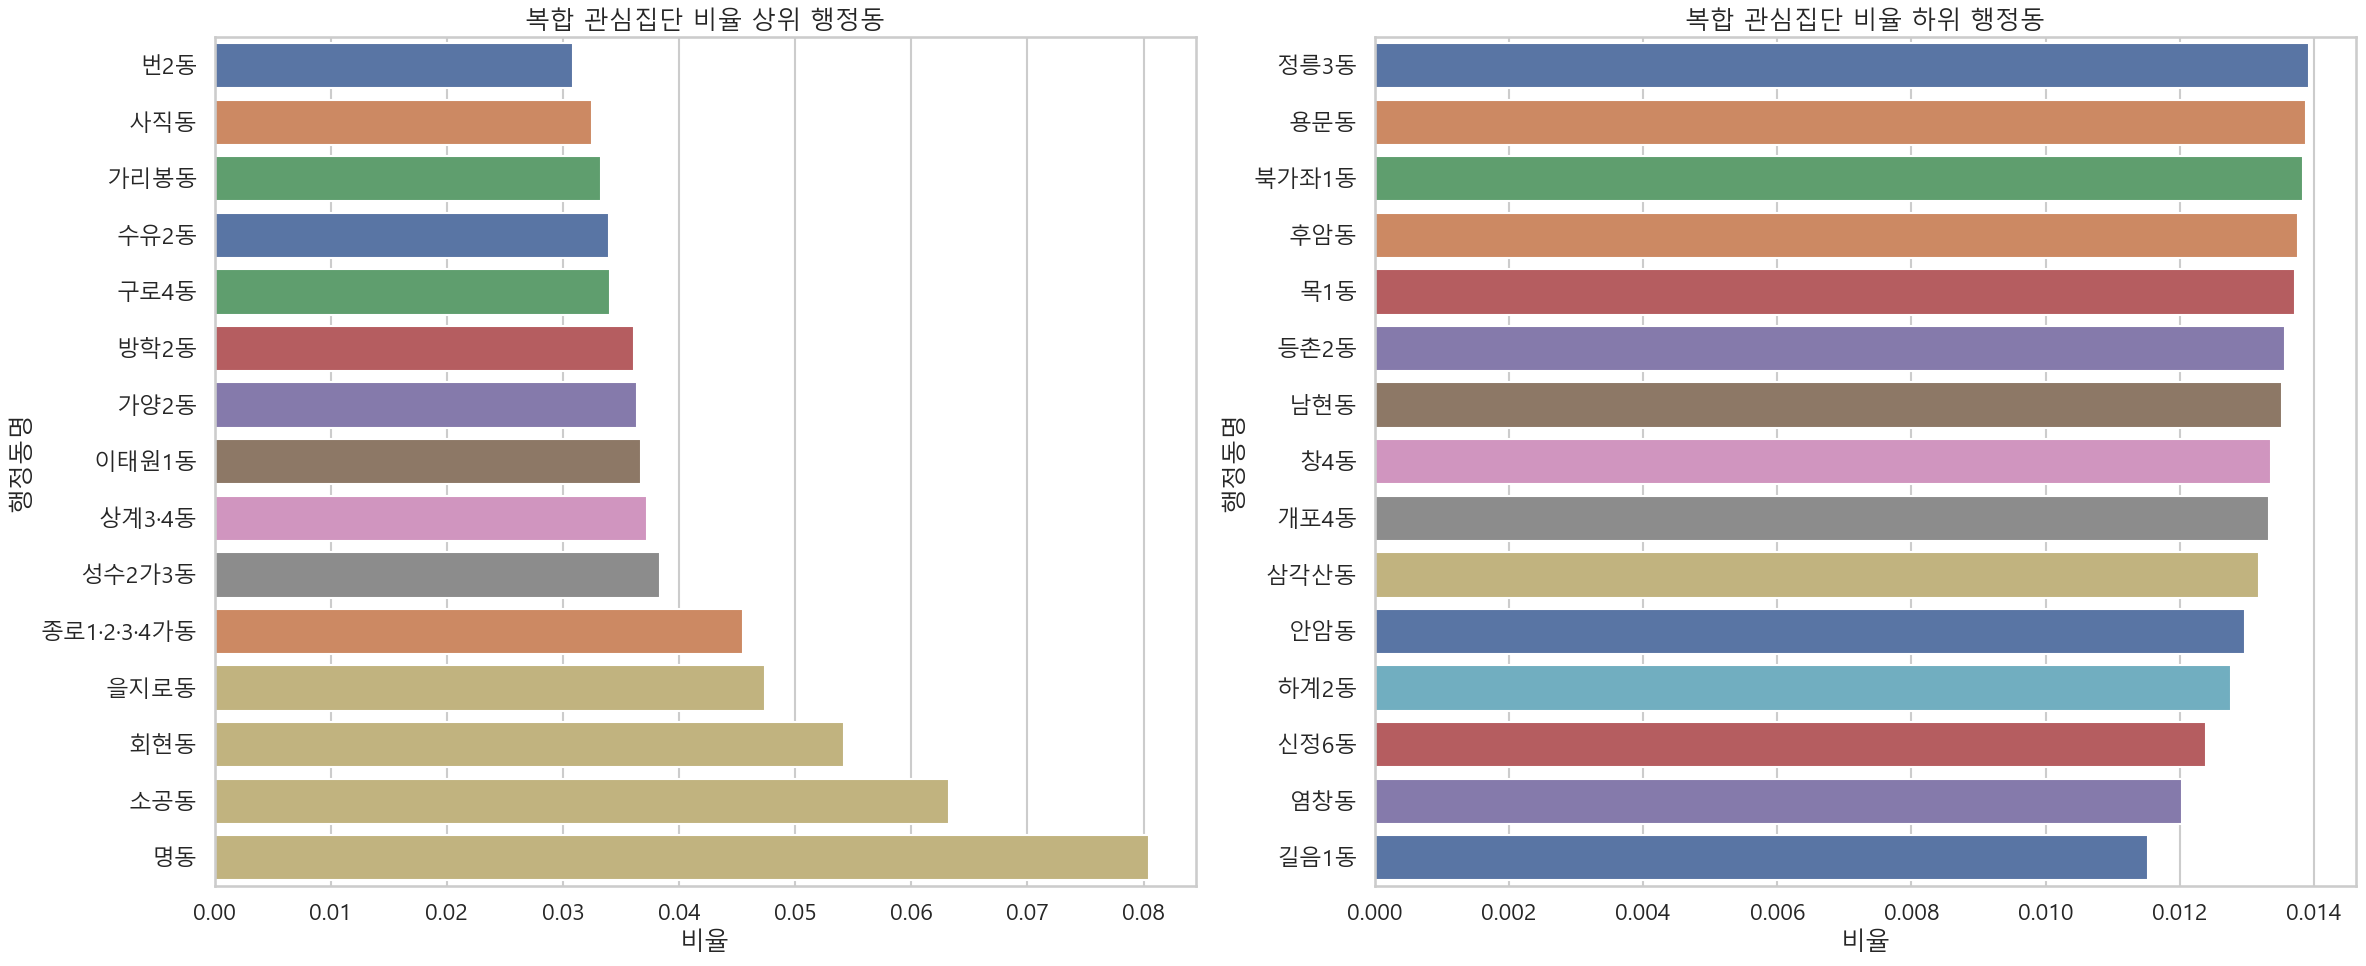

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

sns.barplot(data=top_dong.sort_values(rank_col), x=rank_col, y='행정동명', hue='자치구', dodge=False, ax=axes[0])
axes[0].set_title('복합 관심집단 비율 상위 행정동')
axes[0].set_xlabel('비율')
axes[0].set_ylabel('행정동명')
axes[0].legend_.remove()

sns.barplot(data=bottom_dong.sort_values(rank_col, ascending=False), x=rank_col, y='행정동명', hue='자치구', dodge=False, ax=axes[1])
axes[1].set_title('복합 관심집단 비율 하위 행정동')
axes[1].set_xlabel('비율')
axes[1].set_ylabel('행정동명')
axes[1].legend_.remove()

plt.tight_layout()
plt.show()

## 6. 관심집단 간 관계 분석

비율 기준으로 관심집단 사이의 동행 패턴을 상관관계로 확인합니다.

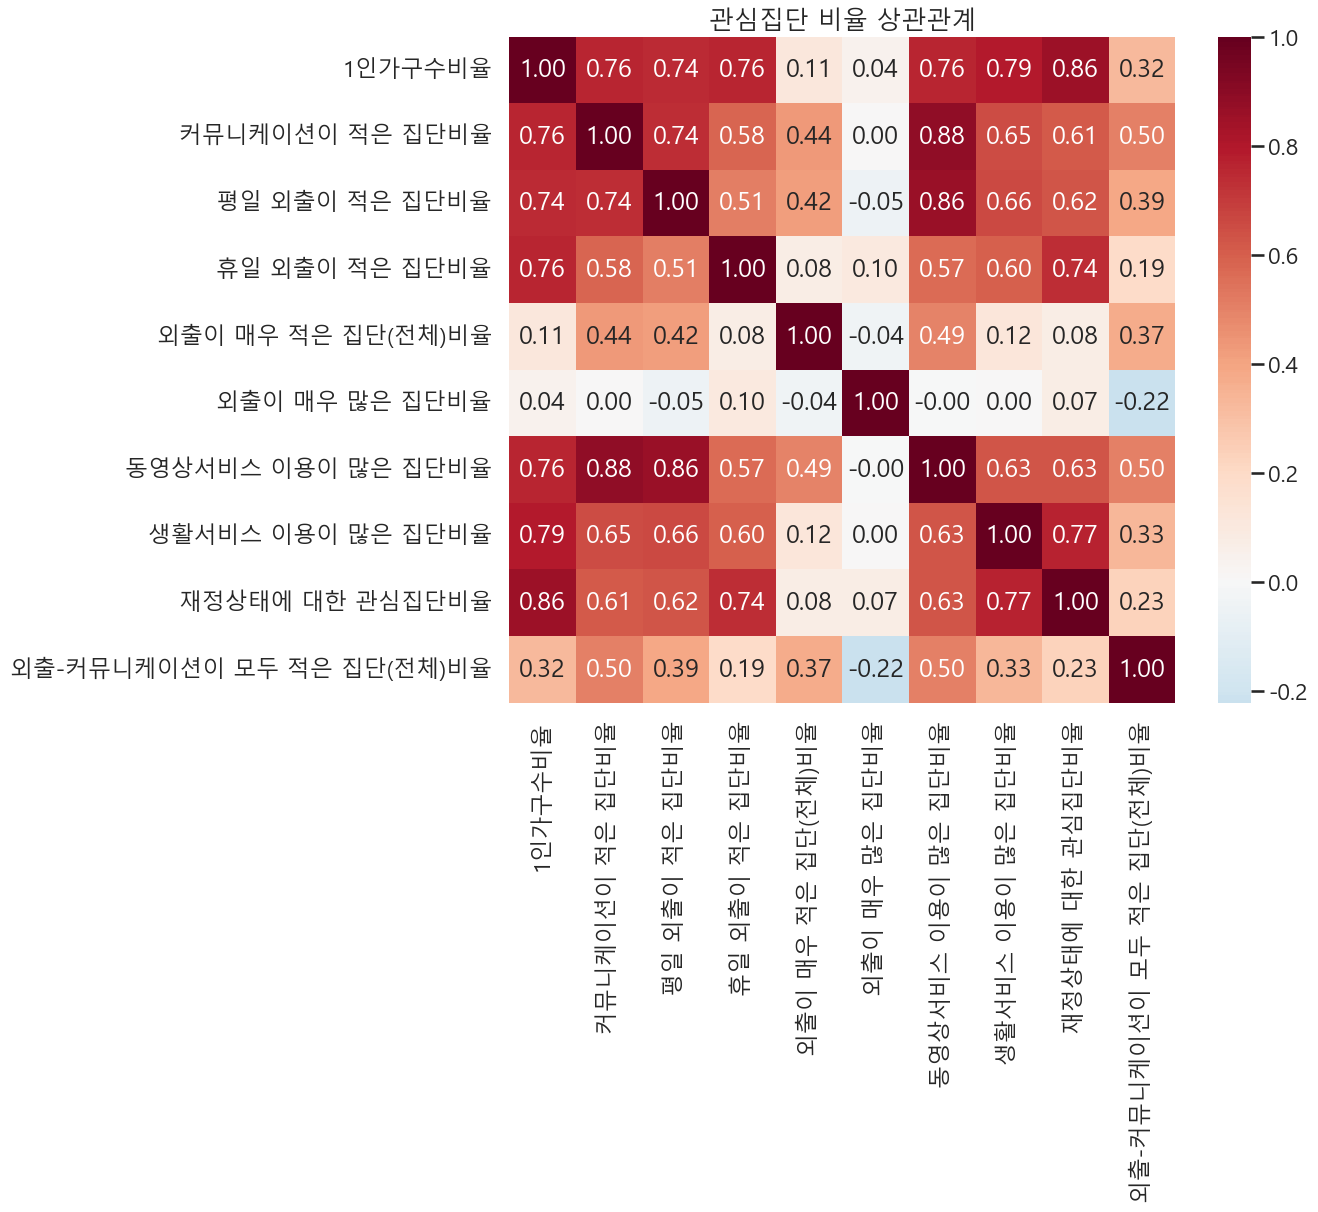

In [13]:
corr_cols = [
    '1인가구수비율',
    '커뮤니케이션이 적은 집단비율',
    '평일 외출이 적은 집단비율',
    '휴일 외출이 적은 집단비율',
    '외출이 매우 적은 집단(전체)비율',
    '외출이 매우 많은 집단비율',
    '동영상서비스 이용이 많은 집단비율',
    '생활서비스 이용이 많은 집단비율',
    '재정상태에 대한 관심집단비율',
    '외출-커뮤니케이션이 모두 적은 집단(전체)비율'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True)
plt.title('관심집단 비율 상관관계')
plt.tight_layout()
plt.show()

## 7. 핵심 인사이트 요약

분석 결과를 빠르게 읽을 수 있도록 주요 포인트를 자동 생성합니다.

In [14]:
district_one = district_df.loc[district_df['1인가구수비율'].idxmax()]
district_fin = district_df.loc[district_df['재정상태에 대한 관심집단비율'].idxmax()]
age_peak = (
    df.groupby('연령대', as_index=False)['커뮤니케이션이 적은 집단비율']
    .mean()
    .sort_values('커뮤니케이션이 적은 집단비율', ascending=False)
    .iloc[0]
)
gender_video = (
    df.groupby('성별라벨', as_index=False)['동영상서비스 이용이 많은 집단비율']
    .mean()
    .sort_values('동영상서비스 이용이 많은 집단비율', ascending=False)
    .iloc[0]
)
top_dong_row = top_dong.iloc[0]

insights = [
    f"1. 1인가구 비율이 가장 높은 자치구는 {district_one['자치구']}이며 비율은 {district_one['1인가구수비율']:.2%}입니다.",
    f"2. 재정상태 관심집단 비율이 가장 높은 자치구는 {district_fin['자치구']}이며 비율은 {district_fin['재정상태에 대한 관심집단비율']:.2%}입니다.",
    f"3. 평균적으로 커뮤니케이션이 적은 집단 비율이 가장 높은 연령대는 {int(age_peak['연령대'])}대이며 비율은 {age_peak['커뮤니케이션이 적은 집단비율']:.2%}입니다.",
    f"4. 동영상서비스 이용이 많은 집단 비율은 {gender_video['성별라벨']}에서 평균 {gender_video['동영상서비스 이용이 많은 집단비율']:.2%}로 가장 높게 나타났습니다.",
    f"5. 총인구 1,000명 이상 기준에서 복합 관심집단 비율이 가장 높은 행정동은 {top_dong_row['자치구']} {top_dong_row['행정동명']}이며 비율은 {top_dong_row[rank_col]:.2%}입니다."
]

for line in insights:
    print(line)

1. 1인가구 비율이 가장 높은 자치구는 관악구이며 비율은 31.78%입니다.
2. 재정상태 관심집단 비율이 가장 높은 자치구는 관악구이며 비율은 3.77%입니다.
3. 평균적으로 커뮤니케이션이 적은 집단 비율이 가장 높은 연령대는 75대이며 비율은 3.66%입니다.
4. 동영상서비스 이용이 많은 집단 비율은 남성에서 평균 2.20%로 가장 높게 나타났습니다.
5. 총인구 1,000명 이상 기준에서 복합 관심집단 비율이 가장 높은 행정동은 중구 명동이며 비율은 8.05%입니다.


## 8. 행정동 중심 추가 인사이트

기존 분석을 유지한 상태에서, 행정동 기준으로 더 직접적인 해석이 가능하도록 비교표와 복합지표를 추가합니다.

In [15]:
dong_focus_cols = {
    '1인가구 비율': '1인가구수비율',
    '커뮤니케이션 저활성 비율': '커뮤니케이션이 적은 집단비율',
    '재정 관심 비율': '재정상태에 대한 관심집단비율',
    '외출·커뮤니케이션 동시 저활성 비율': rank_col
}

dong_top_summary = []
for label, col in dong_focus_cols.items():
    top_row = dong_filtered.nlargest(1, col).iloc[0]
    dong_top_summary.append({
        '지표': label,
        '자치구': top_row['자치구'],
        '행정동명': top_row['행정동명'],
        '총인구': int(top_row['총인구']),
        '비율': top_row[col]
    })

dong_top_summary_df = pd.DataFrame(dong_top_summary)
dong_top_summary_df

,지표,자치구,행정동명,총인구,비율
0,1인가구 비율,관악구,신림동,21191,0.6448
1,커뮤니케이션 저활성 비율,중구,명동,4237,0.1234
2,재정 관심 비율,관악구,신림동,21191,0.0924
3,외출·커뮤니케이션 동시 저활성 비율,중구,명동,4237,0.0805


In [16]:
dong_score_cols = [
    '1인가구수비율',
    '커뮤니케이션이 적은 집단비율',
    '재정상태에 대한 관심집단비율',
    rank_col
]

dong_score_df = dong_filtered[['행정동코드', '자치구', '행정동명', '총인구'] + dong_score_cols].copy()

for col in dong_score_cols:
    z_col = f'{col}_z'
    dong_score_df[z_col] = (dong_score_df[col] - dong_score_df[col].mean()) / dong_score_df[col].std(ddof=0)

z_cols = [f'{col}_z' for col in dong_score_cols]
dong_score_df['행정동복합지수'] = dong_score_df[z_cols].mean(axis=1)

type_map = {
    '1인가구수비율_z': '1인가구 집중형',
    '커뮤니케이션이 적은 집단비율_z': '소통 저활성형',
    '재정상태에 대한 관심집단비율_z': '재정 관심형',
    f'{rank_col}_z': '복합 취약형'
}
dong_score_df['대표특성'] = dong_score_df[z_cols].idxmax(axis=1).map(type_map)

dong_score_top15 = dong_score_df.nlargest(15, '행정동복합지수')[['자치구', '행정동명', '총인구', '행정동복합지수', '대표특성']]
dong_score_top15

,자치구,행정동명,총인구,행정동복합지수,대표특성
19,중구,명동,4237,4.7353,복합 취약형
23,중구,을지로동,3102,4.4061,소통 저활성형
17,중구,소공동,2940,4.2364,소통 저활성형
7,종로구,종로1·2·3·4가동,10490,3.6177,소통 저활성형
329,관악구,신림동,21191,3.3195,재정 관심형
275,금천구,가산동,26693,2.4196,재정 관심형
332,관악구,대학동,24125,2.3661,재정 관심형
65,광진구,화양동,27574,2.3345,재정 관심형
18,중구,회현동,4947,2.3111,복합 취약형
364,강남구,역삼1동,38753,2.1611,1인가구 집중형


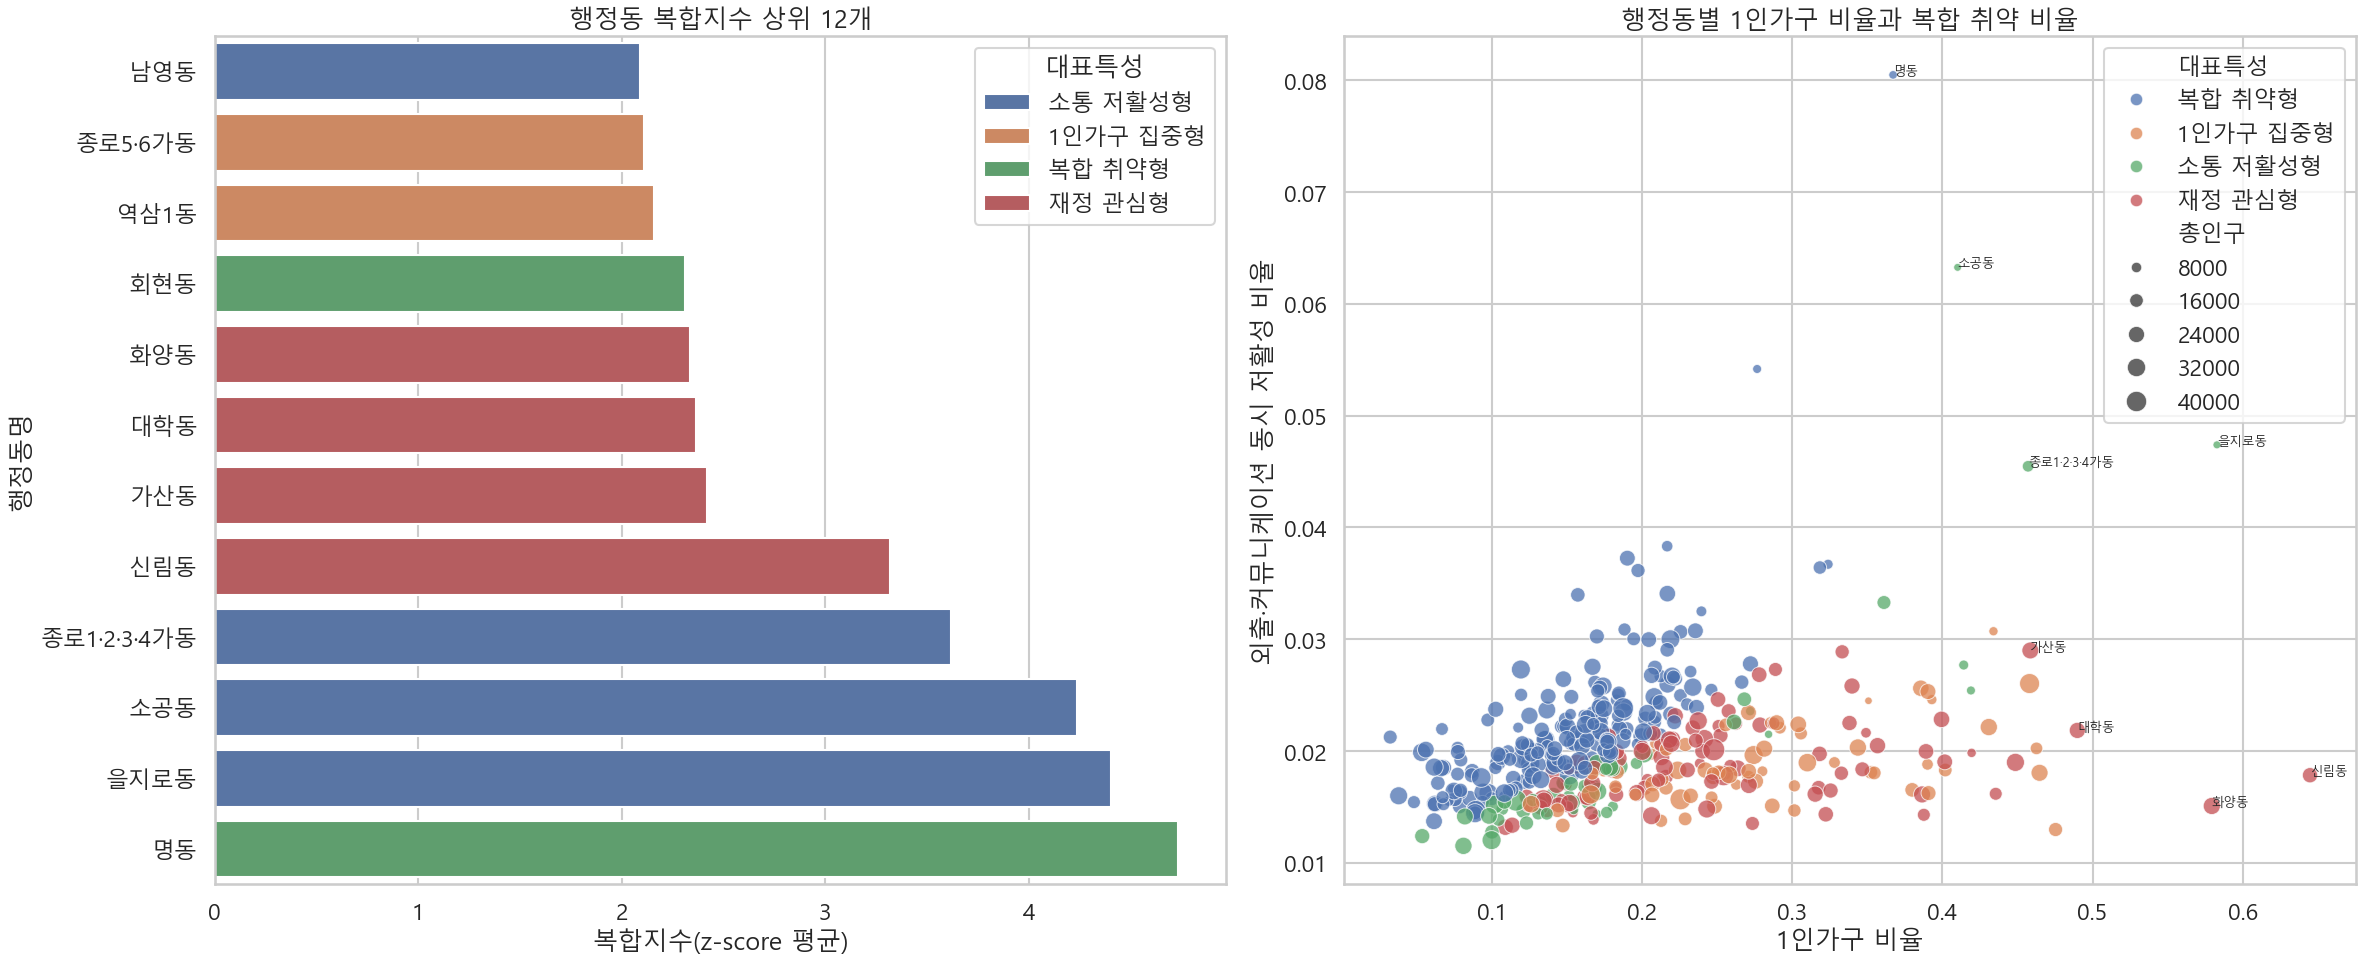

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

plot_df = dong_score_df.nlargest(12, '행정동복합지수').sort_values('행정동복합지수')
sns.barplot(data=plot_df, x='행정동복합지수', y='행정동명', hue='대표특성', dodge=False, ax=axes[0])
axes[0].set_title('행정동 복합지수 상위 12개')
axes[0].set_xlabel('복합지수(z-score 평균)')
axes[0].set_ylabel('행정동명')

scatter_df = dong_score_df.copy()
sns.scatterplot(
    data=scatter_df,
    x='1인가구수비율',
    y=rank_col,
    hue='대표특성',
    size='총인구',
    sizes=(30, 250),
    alpha=0.75,
    ax=axes[1]
)
axes[1].set_title('행정동별 1인가구 비율과 복합 취약 비율')
axes[1].set_xlabel('1인가구 비율')
axes[1].set_ylabel('외출·커뮤니케이션 동시 저활성 비율')

for _, row in dong_score_df.nlargest(8, '행정동복합지수').iterrows():
    axes[1].text(row['1인가구수비율'], row[rank_col], row['행정동명'], fontsize=9)

plt.tight_layout()
plt.show()

In [18]:
high_risk_cut = dong_score_df['행정동복합지수'].quantile(0.90)
high_risk_dongs = dong_score_df[dong_score_df['행정동복합지수'] >= high_risk_cut].copy()

top_composite = dong_score_df.nlargest(1, '행정동복합지수').iloc[0]
top_single = dong_filtered.nlargest(1, '1인가구수비율').iloc[0]
top_fin_dong = dong_filtered.nlargest(1, '재정상태에 대한 관심집단비율').iloc[0]
top_comm_dong = dong_filtered.nlargest(1, '커뮤니케이션이 적은 집단비율').iloc[0]
dense_risk_area = high_risk_dongs.groupby('자치구').size().sort_values(ascending=False).reset_index(name='고위험 행정동 수').iloc[0]
dominant_type = dong_score_df['대표특성'].value_counts().reset_index()
dominant_type.columns = ['대표특성', '행정동 수']

print('행정동 기준 핵심 인사이트')
print(f"1. 복합지수 기준 가장 주의가 필요한 행정동은 {top_composite['자치구']} {top_composite['행정동명']}이며, 대표특성은 {top_composite['대표특성']}입니다.")
print(f"2. 1인가구 비율이 가장 높은 행정동은 {top_single['자치구']} {top_single['행정동명']}이며 비율은 {top_single['1인가구수비율']:.2%}입니다.")
print(f"3. 재정 관심집단 비율이 가장 높은 행정동은 {top_fin_dong['자치구']} {top_fin_dong['행정동명']}이며 비율은 {top_fin_dong['재정상태에 대한 관심집단비율']:.2%}입니다.")
print(f"4. 커뮤니케이션 저활성 비율이 가장 높은 행정동은 {top_comm_dong['자치구']} {top_comm_dong['행정동명']}이며 비율은 {top_comm_dong['커뮤니케이션이 적은 집단비율']:.2%}입니다.")
print(f"5. 복합지수 상위 10% 행정동이 가장 많이 분포한 자치구는 {dense_risk_area['자치구']}이며, 해당 자치구에는 {int(dense_risk_area['고위험 행정동 수'])}개의 고위험 행정동이 있습니다.")

display(dominant_type)

행정동 기준 핵심 인사이트
1. 복합지수 기준 가장 주의가 필요한 행정동은 중구 명동이며, 대표특성은 복합 취약형입니다.
2. 1인가구 비율이 가장 높은 행정동은 관악구 신림동이며 비율은 64.48%입니다.
3. 재정 관심집단 비율이 가장 높은 행정동은 관악구 신림동이며 비율은 9.24%입니다.
4. 커뮤니케이션 저활성 비율이 가장 높은 행정동은 중구 명동이며 비율은 12.34%입니다.
5. 복합지수 상위 10% 행정동이 가장 많이 분포한 자치구는 관악구이며, 해당 자치구에는 11개의 고위험 행정동이 있습니다.


,대표특성,행정동 수
0,복합 취약형,203
1,재정 관심형,102
2,1인가구 집중형,68
3,소통 저활성형,51
